In [128]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('/content/train.csv', header = None)

# Check the number of rows and columns in the dataset
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Check for missing or null values
print(df.isnull().sum())

# Look at the first few rows of the data
print(df.head())

Number of rows: 27995
Number of columns: 122
0          0
1          0
2      16280
3      18609
4      14132
       ...  
117        1
118       84
119    13831
120        1
121        1
Length: 122, dtype: int64
      0     1       2       3     4   5     6       7    8    9    ...  112  \
0   69769  -946  0.1613  0.7960  Panl   N  Bus2  0.0742    0    2  ...  1.0   
1  236977   -92     NaN     NaN   NaN   Y  Othr     NaN    0    3  ...  NaN   
2  168821 -1646  0.1124  0.8504  Panl   N  Bus3  0.0387    0    2  ...  2.0   
3   94708 -1651  0.0263     NaN  Blok   N  Bus3     NaN    0    2  ...  4.0   
4   84556  -977     NaN     NaN   NaN   N  Rest     NaN    0    2  ...  NaN   

      113     114  115  116   117  118     119  120  121  
0 -4670.0  0.9851  0.0  0.0  Mard  0.0  0.3333  0.0  0.0  
1 -1994.0     NaN  NaN  0.0  Mard  0.0     NaN  0.0  0.0  
2 -2842.0  0.9891  0.0  0.0  Sind  0.0  0.3750  0.0  1.0  
3 -1345.0  0.9682  0.0  0.0  Sind  0.0  0.0417  0.0  1.0  
4  -852.0     Na

In [130]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,112,113,114,115,116,117,118,119,120,121
0,69769,-946,0.1613,0.796000,Panl,N,Bus2,0.074200,0,2,...,1.0,-4670.0,0.9851,0.0000,0.0,Mard,0.0,0.3333,0.0,0.0
2,168821,-1646,0.1124,0.850400,Panl,N,Bus3,0.038700,0,2,...,2.0,-2842.0,0.9891,0.0000,0.0,Sind,0.0,0.3750,0.0,1.0
3,94708,-1651,0.0263,0.751125,Blok,N,Bus3,0.041902,0,2,...,4.0,-1345.0,0.9682,0.0000,0.0,Sind,0.0,0.0417,0.0,1.0
5,114510,365243,0.1067,0.809600,Panl,N,XNAA,0.052500,0,2,...,2.0,-4138.0,0.9861,0.0000,0.0,Mard,0.0,0.4583,0.0,0.0
6,237407,-2285,0.0806,0.751125,Stok,Y,Tra3,0.041902,1,2,...,0.0,-4328.0,0.9747,0.0033,0.0,Cive,1.0,0.1667,0.0,0.0


In [8]:
binary_label = df.iloc[:, -1]
print(binary_label)

0        0.0
1        0.0
2        1.0
3        1.0
4        0.0
        ... 
27990    1.0
27991    0.0
27992    0.0
27993    0.0
27994    NaN
Name: 121, Length: 27995, dtype: float64


In [34]:
df.dropna(subset=[121], inplace=True)



In [35]:
print(binary_label)

0        0.0
1        0.0
2        1.0
3        1.0
4        0.0
        ... 
27990    1.0
27991    0.0
27992    0.0
27993    0.0
27994    0.0
Name: 121, Length: 27995, dtype: float64



We found out which data is nan
We have decided that it is not appropriate to fill in the label, because it can manipulate the data.


In [37]:
df[121].isnull().sum()

0

In [9]:
print(binary_label.value_counts())

0.0    25750
1.0     2244
Name: 121, dtype: int64


In [10]:
column_names = df.columns

print(column_names)

Int64Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
            ...
            112, 113, 114, 115, 116, 117, 118, 119, 120, 121],
           dtype='int64', length=122)


In [38]:
last_column_name = df.columns[-1]

print(last_column_name)

121


<Axes: xlabel='121', ylabel='count'>

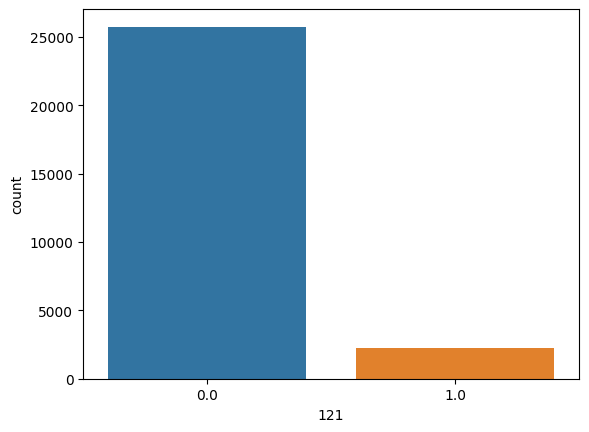

In [12]:
import seaborn as sns
sns.countplot(x=binary_label)

In [33]:
# check for empty data in each row
empty_rows = df[df.isna().any(axis=1)]

# print the empty rows
print(empty_rows)

          0       1       2       3     4   5     6       7    8    9    ...  \
0       69769    -946  0.1613  0.7960  Panl   N  Bus2  0.0742    0    2  ...   
1      236977     -92     NaN     NaN   NaN   Y  Othr     NaN    0    3  ...   
2      168821   -1646  0.1124  0.8504  Panl   N  Bus3  0.0387    0    2  ...   
3       94708   -1651  0.0263     NaN  Blok   N  Bus3     NaN    0    2  ...   
4       84556    -977     NaN     NaN   NaN   N  Rest     NaN    0    2  ...   
...       ...     ...     ...     ...   ...  ..   ...     ...  ...  ...  ...   
27990  252281   -1828     NaN     NaN   NaN   N  Bus3     NaN    0    2  ...   
27991   31246  365243     NaN     NaN   NaN   N  XNAA     NaN    0    2  ...   
27992  234895    -132  0.0727     NaN  Panl   N  Rest     NaN    0    2  ...   
27993   27880   -5298     NaN     NaN   NaN   N  Ind3     NaN    0    2  ...   
27994   28953  365243     NaN     NaN   NaN   N  XNAA     NaN    0    2  ...   

       112     113     114     115  116

In [20]:
mode_value = df[121].mode()[0]
mode_value

0.0

In [21]:
# Fill the missing values with the mode value
df[121].fillna(mode_value, inplace=True)

In [22]:
df[121].isnull().sum()

0

<Axes: xlabel='121', ylabel='count'>

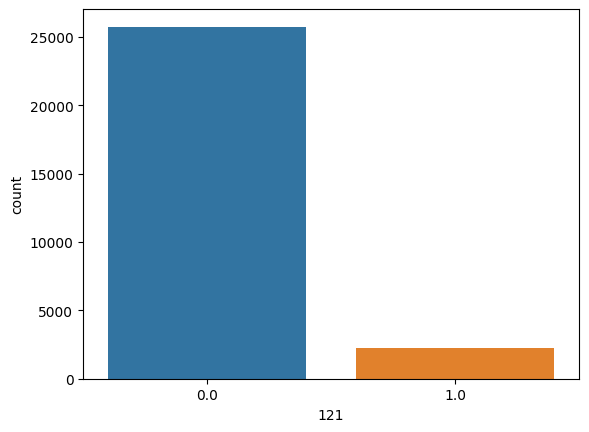

In [14]:
sns.countplot(x=binary_label)

In [25]:
null_count = df[:].isnull().sum()

print(null_count)

0          0
1          0
2      16280
3      18609
4      14132
       ...  
117        1
118       84
119    13831
120        1
121        0
Length: 122, dtype: int64


In [26]:
missing_percentage = null_count / len(df.columns)

In [60]:
# select the columns where the percent of missing values is less than 30%
missing_cols_lower_30 = missing_percentage[missing_percentage < 0.3].index.tolist()
print(missing_cols_lower_30)

[0, 1, 5, 6, 8, 9, 13, 15, 19, 20, 23, 24, 26, 28, 29, 30, 31, 33, 37, 40, 41, 42, 46, 47, 50, 52, 53, 55, 57, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 75, 76, 81, 85, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 113, 116, 117, 120, 121]


In [61]:
# select the columns where the percent of missing values is less than 20%
missing_cols_lower_20 = missing_percentage[missing_percentage < 0.2].index.tolist()
print(missing_cols_lower_20)

[0, 1, 5, 6, 8, 9, 15, 19, 20, 23, 24, 26, 28, 29, 30, 31, 33, 37, 40, 41, 42, 46, 47, 50, 52, 53, 55, 57, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 75, 76, 81, 85, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 113, 116, 117, 120, 121]


In [62]:
# select the columns where the percent of missing values is less than 10%
missing_cols_lower_10 = missing_percentage[missing_percentage < 0.1].index.tolist()
print(missing_cols_lower_10)

[0, 1, 5, 6, 8, 9, 15, 19, 20, 23, 24, 26, 28, 29, 30, 31, 33, 37, 40, 41, 42, 46, 47, 50, 52, 53, 55, 57, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 75, 76, 81, 85, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 113, 116, 117, 120, 121]


In [63]:
# select the columns where the percent of missing values is less than 5%
missing_cols_lower_5 = missing_percentage[missing_percentage < 0.05].index.tolist()
print(missing_cols_lower_5)

[0, 1, 5, 6, 8, 9, 15, 19, 20, 23, 24, 26, 28, 29, 30, 31, 33, 37, 40, 41, 42, 46, 47, 50, 52, 53, 55, 57, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 75, 76, 81, 85, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 113, 116, 117, 120, 121]


In [64]:
# select the columns where the percent of missing values is greater than 30%
missing_cols_upper_30 = missing_percentage[missing_percentage > 0.3].index.tolist()
print(missing_cols_upper_30)

[2, 3, 4, 7, 10, 11, 12, 14, 16, 17, 18, 21, 22, 25, 27, 32, 34, 35, 36, 38, 39, 43, 44, 45, 48, 49, 51, 54, 56, 58, 59, 60, 61, 68, 72, 74, 77, 78, 79, 80, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 95, 96, 101, 102, 107, 109, 110, 111, 112, 114, 115, 118, 119]


In [42]:
empty_cells_0 = df.iloc[0].isna()

# print the empty cells
print(empty_cells_0)

0      False
1      False
2      False
3      False
4      False
       ...  
117    False
118    False
119    False
120    False
121    False
Name: 0, Length: 122, dtype: bool


In [43]:
empty_count_0 = df[0].isna().sum()

# print the number of empty values
print(empty_count_0)

0


In [46]:
df.iloc[1].isna()



0      False
1      False
2       True
3       True
4       True
       ...  
117    False
118    False
119     True
120    False
121    False
Name: 1, Length: 122, dtype: bool


In [51]:
df[1].isna().sum()



0


In [53]:
df[119].isna().sum()

13831

In [58]:
df[119]

0        0.3333
1           NaN
2        0.3750
3        0.0417
4           NaN
          ...  
27990    0.1667
27991       NaN
27992    0.1667
27993       NaN
27994       NaN
Name: 119, Length: 27995, dtype: float64

In [59]:
empty_cells=df[119].isna().sum()

13831

In [65]:
df[2]

0        0.1613
1           NaN
2        0.1124
3        0.0263
4           NaN
          ...  
27990       NaN
27991       NaN
27992    0.0727
27993       NaN
27994       NaN
Name: 2, Length: 27995, dtype: float64

In [66]:
df[2].isna().sum()



16280

In [67]:
df.iloc[2].isna()


0      False
1      False
2      False
3      False
4      False
       ...  
117    False
118    False
119    False
120    False
121    False
Name: 2, Length: 122, dtype: bool

In [81]:
# select the columns where the percent of missing values is greater than 30%
missing_cols_upper_30 = missing_percentage[missing_percentage > 0.3].index.tolist()
print(missing_cols_upper_30)

[2, 3, 4, 7, 10, 11, 12, 14, 16, 17, 18, 21, 22, 25, 27, 32, 34, 35, 36, 38, 39, 43, 44, 45, 48, 49, 51, 54, 56, 58, 59, 60, 61, 68, 72, 74, 77, 78, 79, 80, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 95, 96, 101, 102, 107, 109, 110, 111, 112, 114, 115, 118, 119]


In [70]:
mean_2 = df[2].mean()
df[2].fillna(mean_2, inplace=True)

In [71]:
df[2].isna().sum()


0

In [72]:
mean_3 = df[3].mean()
df[3].fillna(mean_3, inplace=True)

In [73]:
df[3].isna().sum()


0

In [74]:
df[4].isna().sum()

14132

In [76]:
df[4]

0        Panl
1         NaN
2        Panl
3        Blok
4         NaN
         ... 
27990     NaN
27991     NaN
27992    Panl
27993     NaN
27994     NaN
Name: 4, Length: 27995, dtype: object

In [77]:
df[7].isna().sum()

19492

In [79]:
mean_7 = df[7].mean()
df[7].fillna(mean_7, inplace=True)

In [80]:
df[7].isna().sum()

0

In [93]:
for col in missing_cols_upper_30:
    if df[col].dtype == 'float' or df[col].dtype == 'int':
        mean = df[col].mean()
        df[col].fillna(mean, inplace=True)

In [92]:
# Check if any missing values are still present in the columns
missing_values = df[missing_cols_upper_30].isna().values.sum()
if missing_values > 0:
    print(f"There are still {missing_values} missing values in columns {missing_cols_upper_30}")
else:
    print("All missing values have been filled with their mean")


There are still 69169 missing values in columns [2, 3, 4, 7, 10, 11, 12, 14, 16, 17, 18, 21, 22, 25, 27, 32, 34, 35, 36, 38, 39, 43, 44, 45, 48, 49, 51, 54, 56, 58, 59, 60, 61, 68, 72, 74, 77, 78, 79, 80, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 95, 96, 101, 102, 107, 109, 110, 111, 112, 114, 115, 118, 119]


In [96]:
df[49].isnull()

0        False
1        False
2        False
3        False
4        False
         ...  
27990    False
27991    False
27992    False
27993    False
27994    False
Name: 49, Length: 27995, dtype: bool

In [90]:
df[51].isna().sum()

0

In [97]:
for col in missing_cols_lower_5:
    if df[col].dtype == 'float' or df[col].dtype == 'int':
        mode = df[col].mode()
        df[col].fillna(mode, inplace=True)

In [98]:
# select the columns where the percent of missing values is less than 5%
missing_cols_lower_5 = missing_percentage[missing_percentage < 0.05].index.tolist()
print(missing_cols_lower_5)

[0, 1, 5, 6, 8, 9, 15, 19, 20, 23, 24, 26, 28, 29, 30, 31, 33, 37, 40, 41, 42, 46, 47, 50, 52, 53, 55, 57, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 75, 76, 81, 85, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 113, 116, 117, 120, 121]


In [99]:
df[15].isna().sum()

0

In [100]:
# select the columns where the percent of missing values is less than 5%
missing_cols_upper_5 = missing_percentage[missing_percentage > 0.05].index.tolist()
print(missing_cols_upper_5)

[2, 3, 4, 7, 10, 11, 12, 13, 14, 16, 17, 18, 21, 22, 25, 27, 32, 34, 35, 36, 38, 39, 43, 44, 45, 48, 49, 51, 54, 56, 58, 59, 60, 61, 68, 72, 74, 77, 78, 79, 80, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 95, 96, 101, 102, 107, 109, 110, 111, 112, 114, 115, 118, 119]


In [101]:
for col in missing_cols_upper_5:
    if df[col].dtype == 'float' or df[col].dtype == 'int':
        mean = df[col].mean()
        df[col].fillna(mean, inplace=True)

In [107]:
num_missing_per_column = df.isna().sum()

# count the total number of missing values in the dataframe
total_num_missing = num_missing_per_column.sum()

# print the results
print('Number of missing values per column:')
print(num_missing_per_column)
print('Total number of missing values in the dataframe:', total_num_missing)

Number of missing values per column:
0          0
1          0
2          0
3          0
4      14132
       ...  
117        1
118        0
119        0
120        1
121        0
Length: 122, dtype: int64
Total number of missing values in the dataframe: 69199


In [108]:
df[4]

0        Panl
1         NaN
2        Panl
3        Blok
4         NaN
         ... 
27990     NaN
27991     NaN
27992    Panl
27993     NaN
27994     NaN
Name: 4, Length: 27995, dtype: object

In [114]:
df[4].isna().sum()

14132

In [117]:
df[4].isna().sum()/len(df[4])


0.5048044293623861

In [119]:
object_col=df[4]

In [120]:
print(object_col.value_counts())

Stok    5984
Panl    5944
Blok     851
Woon     530
Mixd     227
Monc     165
Oths     162
Name: 4, dtype: int64


In [124]:
df.dropna(subset=[4], inplace=True)



the empty data was half of all the data. when I examined the filled data, I saw that the number of two data was very close to each other. if I filled the empty data with one of them, the dataset would be corrupted. Because of that I cleaned it.

In [125]:
df[4].isnull().sum()

0

In [132]:
df.columns

Int64Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
            ...
            112, 113, 114, 115, 116, 117, 118, 119, 120, 121],
           dtype='int64', length=122)

In [135]:
df.index

Int64Index([    0,     2,     3,     5,     6,     8,    13,    15,    20,
               23,
            ...
            27977, 27978, 27979, 27981, 27982, 27984, 27986, 27987, 27989,
            27992],
           dtype='int64', length=13863)

In [137]:
num_missing_per_column = df.isna().sum()

# count the total number of missing values in the dataframe
total_num_missing = num_missing_per_column.sum()

# print the results
print('Number of missing values per column:')
print(num_missing_per_column)
print('Total number of missing values in the dataframe:', total_num_missing)

Number of missing values per column:
0      0
1      0
2      0
3      0
4      0
      ..
117    0
118    0
119    0
120    0
121    0
Length: 122, dtype: int64
Total number of missing values in the dataframe: 9560


In [136]:
f_stat, p_val = f_oneway(df.columns, df.index)

print('F-statistic:', f_stat)
print('p-value:', p_val)

F-statistic: 359.79781458761545
p-value: 3.071674097163185e-79


this is one-way anova

In [138]:
df

,0,1,2,3,4,5,6,7,8,9,...,112,113,114,115,116,117,118,119,120,121
0,69769,-946,0.161300,0.796000,Panl,N,Bus2,0.074200,0,2,...,1.0,-4670.0,0.9851,0.00000,0.0,Mard,0.0,0.3333,0.0,0.0
2,168821,-1646,0.112400,0.850400,Panl,N,Bus3,0.038700,0,2,...,2.0,-2842.0,0.9891,0.00000,0.0,Sind,0.0,0.3750,0.0,1.0
3,94708,-1651,0.026300,0.751125,Blok,N,Bus3,0.041902,0,2,...,4.0,-1345.0,0.9682,0.00000,0.0,Sind,0.0,0.0417,0.0,1.0
5,114510,365243,0.106700,0.809600,Panl,N,XNAA,0.052500,0,2,...,2.0,-4138.0,0.9861,0.00000,0.0,Mard,0.0,0.4583,0.0,0.0
6,237407,-2285,0.080600,0.751125,Stok,Y,Tra3,0.041902,1,2,...,0.0,-4328.0,0.9747,0.00330,0.0,Cive,1.0,0.1667,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27984,237150,365243,0.084800,0.755200,Stok,N,XNAA,0.031900,0,2,...,0.0,-4456.0,0.9821,0.00690,0.0,Sind,0.0,0.3333,0.0,0.0
27986,127839,365243,0.058200,0.823200,Panl,N,XNAA,0.000000,0,2,...,0.0,-3578.0,0.9871,0.02760,0.0,Sind,0.0,0.0417,0.0,0.0
27987,210460,365243,0.067200,0.751125,Mixd,N,XNAA,0.041902,0,2,...,2.0,-4377.0,0.9777,0.00000,0.0,Widw,4.0,0.1667,0.0,0.0
27989,63658,-1036,0.087026,0.751125,Woon,N,Kinn,0.041902,0,2,...,5.0,-3221.0,0.9662,0.02713,0.0,Mard,1.0,0.0000,0.0,0.0


In [155]:
missing_mask = df.isnull().any()

# select the columns with missing values
missing_cols = df.columns[missing_mask].tolist()

print(missing_cols)

[16, 44, 107, 110]


In [156]:
col_16=df[16]
col_44=df[44]
col_107=df[107]
col_110=df[110]


In [159]:

print(col_16.value_counts())

Unad    11364
Famy     1727
Spor      459
Chin      125
OthB       77
OthA       39
Groe        9
Name: 16, dtype: int64


In [160]:
df[16].isna().sum()

63

In [161]:
df[16].isna().sum()/len(df[16])


0.004544470893745943

In [162]:
df.dropna(subset=[16], inplace=True)

In row 16, the % of empty data was too low, so I removed the empty data

In [163]:
df[16].isna().sum()

0

In [165]:
df[44].isna().sum()


4256

In [168]:

print(col_44.value_counts())

Labs    2428
Salf    1370
Corf    1305
Mans    1081
Dris     781
Higf     638
Accs     498
Medf     378
Secf     243
Clef     226
Coof     214
Prif     133
Secs      67
Lows      64
Waif      51
Reas      39
HR f      37
IT f      33
Name: 44, dtype: int64


In [169]:
df[44].isna().sum()/len(df[44])


0.3084057971014493

DOKUNMUYORUM

In [166]:
df[107].isna().sum()


209

In [170]:

print(col_107.value_counts())

blos    13378
speg      156
tere      119
Name: 107, dtype: int64


In [171]:
df[107].isna().sum()/len(df[107])


0.015144927536231884

In [172]:
df.dropna(subset=[107], inplace=True)

In row 16, the % of empty data was too low, so I removed the empty data

In [173]:
df[107].isna().sum()


0

In [167]:
df[110].isna().sum()

4994

In [175]:

print(col_110.value_counts())

regt    7827
notd     526
orgt     500
Name: 110, dtype: int64


In [176]:
df[110].isna().sum()/len(df[110])


0.35302773894489

In [178]:
bla=df[119]

<Axes: xlabel='119', ylabel='count'>

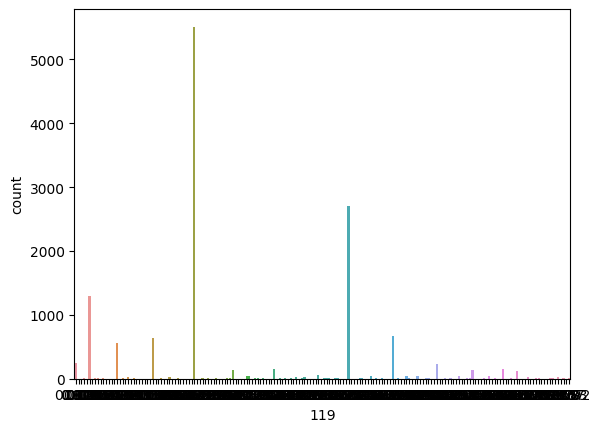

In [179]:
sns.countplot(x=bla)

DOKUNMUYORUM